## Inversion Sampling

In [1]:
# Preamble

%matplotlib inline
%config InlineBackend.figure_formats = ['retina']

import numpy as np

import matplotlib.pyplot as plt

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["olivedrab", "steelblue", "firebrick", "goldenrod"]) 
plt.rcParams['figure.figsize'] = [7,5]
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

### Definitions

Our probability density function according to the Salpeter initial masses formulationis given by

$$p(m) \propto m^{-\alpha}$$

over $m \in [m_1, m_2]$ with a corresponding cumulative distribution function

$$P(m) \propto \frac{m^{1-\alpha} - m_1^{1-\alpha}}{1-\alpha}$$

that must fulfill $P(m_1) = 0$ and $P(m_2) = 1$ per definition. From integrating or simply by reading off, we find

$$\frac{m_2^{1-\alpha} - m_1^{1-\alpha}}{1-\alpha}$$

as the normalization constant, yielding

$$P(m, m_1, m_2) = \frac{m^{1-\alpha} - m_1^{1-\alpha}}{m_2^{1-\alpha} - m_1^{1-\alpha}}$$

for the cumulated distribution. Accordingly, its density is given by

$$p(m, m_1, m_2) = \frac{d}{dm} P(m, m_1, m_2) = \frac{(1-\alpha)m^{-\alpha}}{m_2^{1-\alpha} - m_1^{1-\alpha}}$$

where $m_1 < m_2$ is implied. Inversion of $P(m)$ turns out to be

$$m(P, m_1, m_2) = \left(P (m_2^{1-\alpha} - m_1^{1-\alpha}) +  m_1^{1-\alpha}\right)^{1/(1-\alpha)}$$

and represents the mass distribution. Numerical test parameters:

$$\begin{aligned}
m_1 = 0.1 \,M_\odot && m_2 = 100 \,M_\odot && \alpha = 2.3 && n = 10^6
\end{aligned}$$

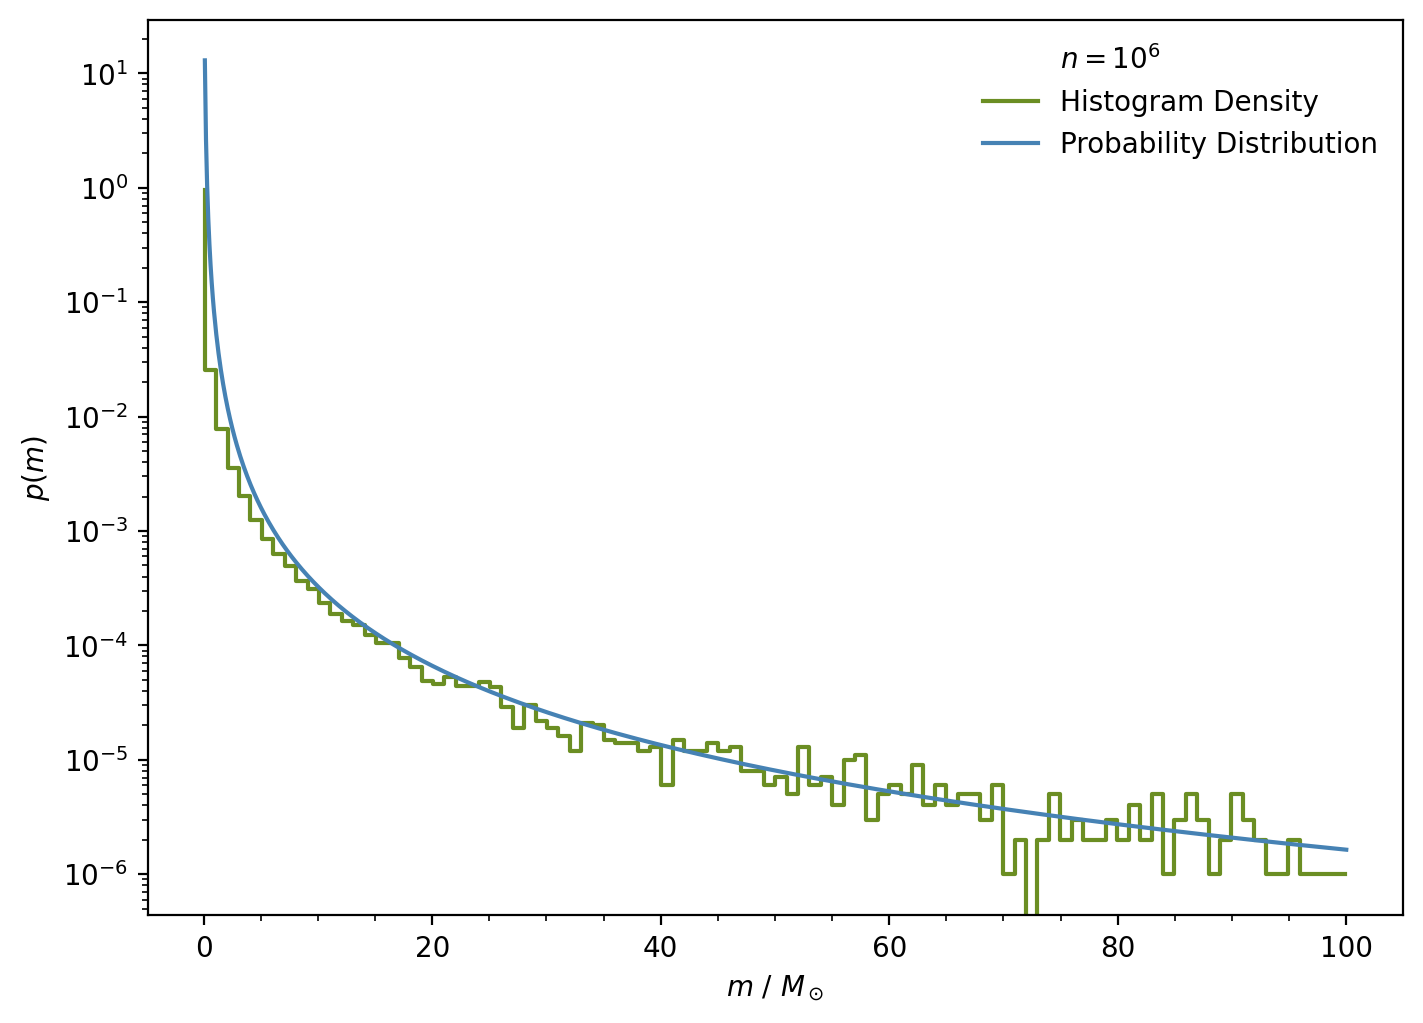

In [2]:
# Application

rng = np.random.default_rng(0)

m1 = 0.1
m2 = 100.0

a = 2.3

n = 10**6

P = rng.uniform(0.0, 1.0, n)

m = (P * (m2**(1-a) - m1**(1-a)) + m1**(1-a))**(1/(1-a))

plt.plot([], [], 'none', label=f'$n = 10^{{{np.log10(n):.0f}}}$')

hist, edge = np.histogram(m, bins=100, density=True)
hist = np.append(hist, hist[-1])

plt.step(edge, hist, label='Histogram Density')

x = np.linspace(m1, m2, 1000)
y = (1-a) * x**(-a) / (m2**(1-a) - m1**(1-a))

plt.plot(x, y, label='Probability Distribution')

plt.xlabel(r'$m$ / $M_\odot$')
plt.ylabel(r'$p(m)$')

plt.yscale('log')

plt.legend()

plt.show()
plt.close()